#Name:Bibek Shrestha
#University ID:2418629



# Part 3 – Sentiment Classification with RNN / LSTM
## Hotel Review Sentiment Analysis

This notebook performs end-to-end text classification using three deep learning models:
**Simple RNN**, **Bidirectional LSTM**, and **LSTM with pretrained GloVe embeddings**.
We classify hotel reviews into Negative (0), Neutral (1), and Positive (2) sentiment classes.

## Step 0 — Install Dependencies & Mount Drive

In [ ]:
!pip install contractions gradio --quiet

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 1 — Imports & Seeds

In [ ]:
import time
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import contractions
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Embedding, SimpleRNN,
                                     LSTM, Dropout, Bidirectional)
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# Seeds for reproducibility
import random
np.random.seed(42)
random.seed(42)

## Step 2 — Dataset Path

In [ ]:
dataset_path = "/content/drive/MyDrive/Ai and ML/Portfolio/2. Hotel Review Dataset/Hotel_Reviews.csv"

## Step 3 — Load & Explore the Dataset

### Dataset Description
The **Hotel Reviews dataset** contains guest reviews collected from a hotel booking platform.
Each row has a free-text **Review** and a **Rating** (1–5 stars).
We convert ratings to three sentiment classes: Negative (≤2), Neutral (=3), Positive (≥4).
The dataset is publicly available and stored on shared Google Drive.

In [ ]:
hotel_data = pd.read_csv(dataset_path, encoding="ISO-8859-1")
print("Dataset shape:", hotel_data.shape)
hotel_data.head()

Dataset shape: (20491, 2)


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


### 3.1 Raw Rating Distribution

Rating value counts:
Rating
5    9054
4    6039
3    2184
2    1793
1    1421
Name: count, dtype: int64


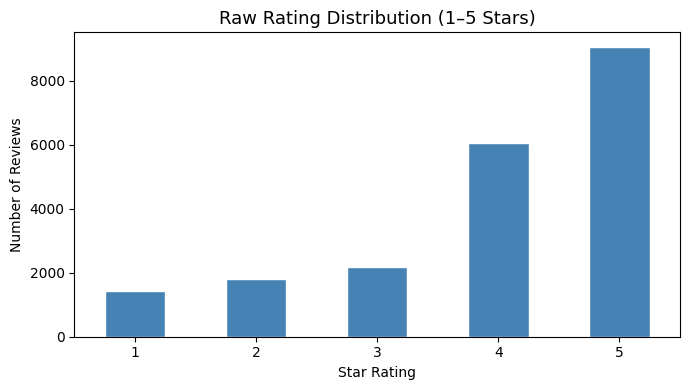

In [ ]:
# Print counts
print("Rating value counts:")
print(hotel_data['Rating'].value_counts())

# Bar chart of raw ratings
plt.figure(figsize=(7, 4))
hotel_data['Rating'].value_counts().sort_index().plot(
    kind='bar', color='steelblue', edgecolor='white')
plt.title("Raw Rating Distribution (1–5 Stars)", fontsize=13)
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 3.2 Missing Value Check

In [ ]:
print("Missing values per column:")
print(hotel_data.isnull().sum())
print()
hotel_data.info()

Missing values per column:
Review    0
Rating    0
dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB


### 3.3 Keep Relevant Columns & Drop NaN Rows

In [ ]:
hotel_data = hotel_data[['Review', 'Rating']].copy()
hotel_data.dropna(inplace=True)
print(f"Rows after dropping NaN: {len(hotel_data)}")
hotel_data.head()

Rows after dropping NaN: 20491


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


## Step 4 — Text Cleaning & Preprocessing

### Preprocessing Steps
1. **Lowercase** — ensures uniformity (e.g. 'Hotel' = 'hotel').
2. **Expand contractions** — 'don't' → 'do not' so tokens are consistent.
3. **Remove URLs, mentions, hashtags** — noise from web-scraped data.
4. **Remove digits and special characters** — retain only alphabetic tokens.
5. **Stopword removal** — high-frequency words (the, is, at) carry no sentiment signal.
6. **Lemmatisation** — reduces words to their base form (running → run, better → good is NOT done here, base form only).

In [ ]:
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',  quiet=True)

stop_word_set = set(stopwords.words('english'))
word_lemmatizer = WordNetLemmatizer()

### `clean_text()` — Regex-Based Cleaning

In [ ]:
def clean_text(raw_text):
    """Lowercase, expand contractions, strip noise."""
    raw_text = str(raw_text).lower()
    raw_text = contractions.fix(raw_text)               # don't → do not
    raw_text = re.sub(r'https?://\S+|www\.\S+', '', raw_text)  # URLs
    raw_text = re.sub(r'@\w+|#\w+', '', raw_text)     # mentions & hashtags
    raw_text = re.sub(r'\d+', '', raw_text)             # digits
    raw_text = re.sub(r'[^a-z\s]', '', raw_text)       # special chars
    raw_text = re.sub(r'\s+', ' ', raw_text).strip()   # extra spaces
    return raw_text

### `preprocess_text()` — Tokenise, Remove Stopwords, Lemmatise

In [ ]:
def preprocess_text(raw_text):
    """Full pipeline: clean → tokenise → stopword removal → lemmatise."""
    cleaned = clean_text(raw_text)
    token_list = cleaned.split()
    token_list = [w for w in token_list if w not in stop_word_set]
    token_list = [word_lemmatizer.lemmatize(w) for w in token_list]
    return " ".join(token_list)

### Apply Preprocessing Pipeline

In [ ]:
print("Cleaning reviews — this may take a few minutes...")
hotel_data['cleaned_review'] = hotel_data['Review'].apply(preprocess_text)
print("Done!")
hotel_data[['Review', 'cleaned_review']].head()

Cleaning reviews — this may take a few minutes...
Done!


,Review,cleaned_review
0,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,nice room experience hotel monaco seattle good...
3,"unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...
4,"great stay great stay, went seahawk game aweso...",great stay great stay went seahawk game awesom...


## Step 5 — Visualise Cleaned Data

### Word Cloud & Top-25 Frequent Words
A **word cloud** gives an immediate visual sense of the most common tokens after cleaning.
The **frequency bar chart** shows exact counts for the top 25 words.

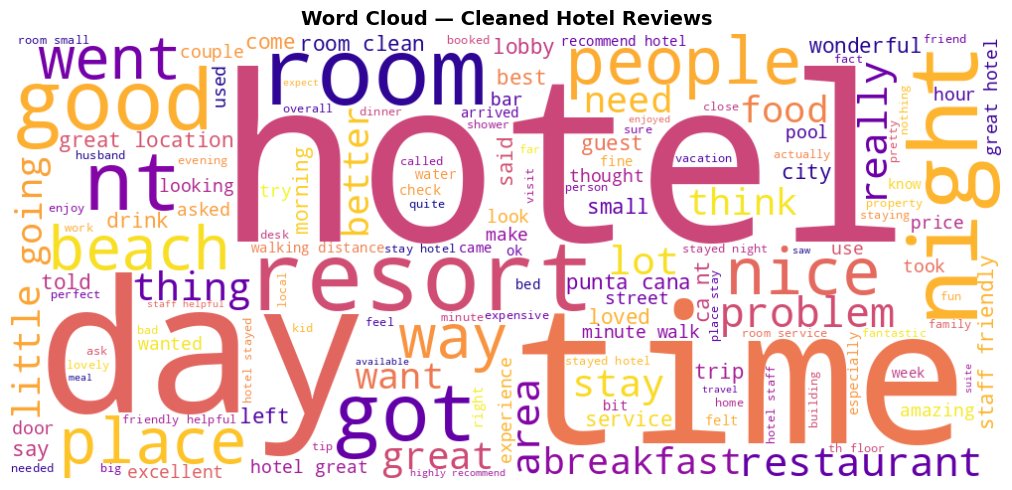

In [ ]:
combined_text = " ".join(hotel_data['cleaned_review'])

# Word Cloud
wc = WordCloud(width=1000, height=450, background_color='white',
               colormap='plasma', max_words=150).generate(combined_text)
plt.figure(figsize=(13, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud — Cleaned Hotel Reviews", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Top-25 Most Frequent Words

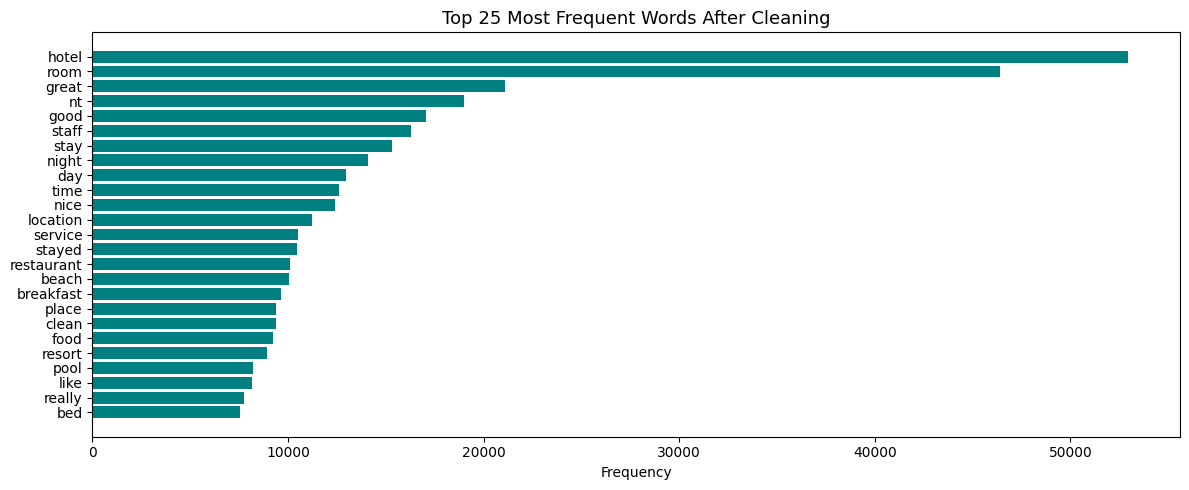

Top 25 words: [('hotel', 52957), ('room', 46378), ('great', 21098), ('nt', 19007), ('good', 17055), ('staff', 16280), ('stay', 15341), ('night', 14084), ('day', 12963), ('time', 12612), ('nice', 12412), ('location', 11236), ('service', 10538), ('stayed', 10469), ('restaurant', 10092), ('beach', 10047), ('breakfast', 9655), ('place', 9381), ('clean', 9373), ('food', 9259), ('resort', 8928), ('pool', 8219), ('like', 8183), ('really', 7766), ('bed', 7524)]


In [ ]:
word_list   = combined_text.split()
top_words   = Counter(word_list).most_common(25)
top_w, top_c = zip(*top_words)

plt.figure(figsize=(12, 5))
plt.barh(list(top_w)[::-1], list(top_c)[::-1], color='teal')
plt.title("Top 25 Most Frequent Words After Cleaning", fontsize=13)
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()

print("Top 25 words:", top_words)

## Step 6 — Label Encoding & Train / Test Split (80 / 20)

We map the 1–5 star ratings to three sentiment labels:
- **0 — Negative** (rating ≤ 2)
- **1 — Neutral**  (rating = 3)
- **2 — Positive** (rating ≥ 4)

The **80/20 split** with `random_state=42` ensures reproducible partitions.

In [ ]:
def map_rating_to_sentiment(rating):
    if rating <= 2:
        return 0   # Negative
    elif rating == 3:
        return 1   # Neutral
    else:
        return 2   # Positive

hotel_data['sentiment'] = hotel_data['Rating'].apply(map_rating_to_sentiment)

reviews  = hotel_data['cleaned_review']
labels   = hotel_data['sentiment']
num_classes = 3

X_train, X_test, y_train, y_test = train_test_split(
    reviews, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

Training samples : 16392
Testing  samples : 4099


### Sentiment Class Distribution After Encoding

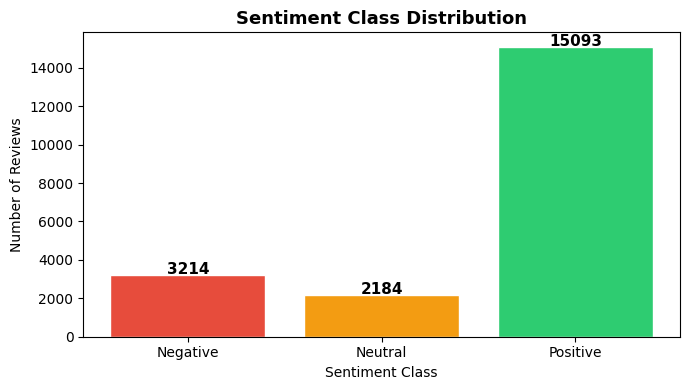

In [ ]:
sentiment_labels = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
counts = hotel_data['sentiment'].value_counts().sort_index()

plt.figure(figsize=(7, 4))
bars = plt.bar([sentiment_labels[i] for i in counts.index],
               counts.values,
               color=['#E74C3C', '#F39C12', '#2ECC71'], edgecolor='white')
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(val), ha='center', fontsize=11, fontweight='bold')
plt.title("Sentiment Class Distribution", fontsize=13, fontweight='bold')
plt.xlabel("Sentiment Class")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

## Step 7 — Keras Tokenisation

`Tokenizer(num_words=8000)` builds a vocabulary of the top **8000** words from the training set.
The `<OOV>` (out-of-vocabulary) token handles unseen words at inference time.

In [ ]:
word_vocab_size = 8000   # top N words to keep

keras_tokenizer = Tokenizer(num_words=word_vocab_size, oov_token="<OOV>")
keras_tokenizer.fit_on_texts(X_train)

train_sequences = keras_tokenizer.texts_to_sequences(X_train)
test_sequences  = keras_tokenizer.texts_to_sequences(X_test)

print(f"Vocabulary size: {len(keras_tokenizer.word_index)}")
print(f"Sample sequence (first train review): {train_sequences[0][:10]} ...")

Vocabulary size: 61586
Sample sequence (first train review): [316, 2, 210, 3, 913, 1, 165, 3, 308, 317] ...


## Step 8 — Percentile-Based Padding

Instead of padding to the maximum length (which may be very long),
we use the **90th percentile** of training sequence lengths as `seq_max_len`.
This avoids extreme padding from outlier-long reviews while retaining 90% of the data intact.

In [ ]:
seq_lengths  = [len(s) for s in train_sequences]
seq_max_len  = int(np.percentile(seq_lengths, 90))
print(f"90th-percentile sequence length (seq_max_len): {seq_max_len}")

X_train_pad = pad_sequences(train_sequences, maxlen=seq_max_len, padding='post', truncating='post')
X_test_pad  = pad_sequences(test_sequences,  maxlen=seq_max_len, padding='post', truncating='post')

print(f"Padded train shape : {X_train_pad.shape}")
print(f"Padded test  shape : {X_test_pad.shape}")

90th-percentile sequence length (seq_max_len): 189
Padded train shape : (16392, 189)
Padded test  shape : (4099, 189)


## Step 9 — Handle Class Imbalance

Hotel reviews are heavily skewed toward Positive ratings.
`compute_class_weight('balanced')` automatically computes higher weights for minority classes
(Negative, Neutral) so the model is penalised more for misclassifying them.

In [ ]:
y_train_flat = y_train.values.flatten()
y_test_flat  = y_test.values.flatten()

label_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_flat),
    y=y_train_flat
)
label_weights = dict(enumerate(label_weights_arr))
print("Class weights:", label_weights)

Class weights: {0: np.float64(2.1252430960715674), 1: np.float64(3.1276473955352033), 2: np.float64(0.4525426536359119)}


## Step 10 — Shared Helper Functions

We define `draw_history()` and `assess_model()` **once** here and reuse them for all 3 models.
This avoids code duplication and keeps the notebook clean.

In [ ]:
def draw_history(hist, title):
    """Plot train vs validation accuracy and loss side-by-side."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(hist.history['accuracy'],     label='Train',      color='steelblue')
    axes[0].plot(hist.history['val_accuracy'], label='Validation', color='darkorange')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(hist.history['loss'],     label='Train',      color='steelblue')
    axes[1].plot(hist.history['val_loss'], label='Validation', color='darkorange')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.suptitle(f"{title} Training Curves", fontweight='bold')
    plt.tight_layout()
    plt.show()


def assess_model(model, X_te, y_te, model_name, class_labels=None):
    """Print classification report and show confusion matrix heatmap."""
    if class_labels is None:
        class_labels = ['Negative', 'Neutral', 'Positive']

    raw_probs   = model.predict(X_te, verbose=0)
    pred_labels = np.argmax(raw_probs, axis=1)

    print(f"\n{'='*55}")
    print(f"  {model_name} — Classification Report")
    print(f"{'='*55}")
    print(classification_report(y_te, pred_labels, target_names=class_labels))

    cm = confusion_matrix(y_te, pred_labels)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels,
                linewidths=0.5)
    plt.title(f'{model_name} — Confusion Matrix', fontsize=13, fontweight='bold')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

    return pred_labels

## Step 11 — Model 1: Simple RNN

### Architecture Rationale
- **Embedding(8000, 64, input_length=seq_max_len)**: Trainable lookup table mapping word indices to 64-d vectors. `input_length` is set to avoid Keras shape warnings.
- **SimpleRNN(32)**: Processes tokens sequentially. Fast but suffers from the **vanishing gradient problem** on long sequences — context from early tokens fades.
- **Dropout(0.2)**: Light regularisation to reduce overfitting.
- **Dense(64, relu) → Dense(3, softmax)**: Classification head.

In [ ]:
embed_size = 64   # embedding dimensionality for Models 1 & 2

rnn_model = Sequential([
    Embedding(input_dim=word_vocab_size, output_dim=embed_size,
              input_length=seq_max_len),
    SimpleRNN(32),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
], name="Simple_RNN")

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop_rnn = EarlyStopping(monitor='val_loss', patience=4,
                                restore_best_weights=True)

t_rnn_start = time.time()
rnn_history = rnn_model.fit(
    X_train_pad, y_train_flat,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop_rnn],
    class_weight=label_weights
)
t_rnn_end = time.time()
rnn_train_time = t_rnn_end - t_rnn_start
print(f"Simple RNN training time: {rnn_train_time:.1f} seconds")

Epoch 1/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.3734 - loss: 1.1007 - val_accuracy: 0.5252 - val_loss: 1.0766
Epoch 2/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.4182 - loss: 1.0825 - val_accuracy: 0.4684 - val_loss: 1.0877
Epoch 3/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.4499 - loss: 1.0719 - val_accuracy: 0.4138 - val_loss: 1.1086
Epoch 4/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.4547 - loss: 1.0255 - val_accuracy: 0.4599 - val_loss: 1.0781
Epoch 5/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4525 - loss: 0.9819 - val_accuracy: 0.7121 - val_loss: 1.0547
Epoch 6/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5216 - loss: 0.9655 - val_accuracy: 0.1568 - val_loss: 1.1088
Epoch 7/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5206 - loss: 0.9607 - val_accuracy: 0.4474 - val_loss: 1.1161
Epoch 8/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.4986 - loss: 0.9568 - val_acc

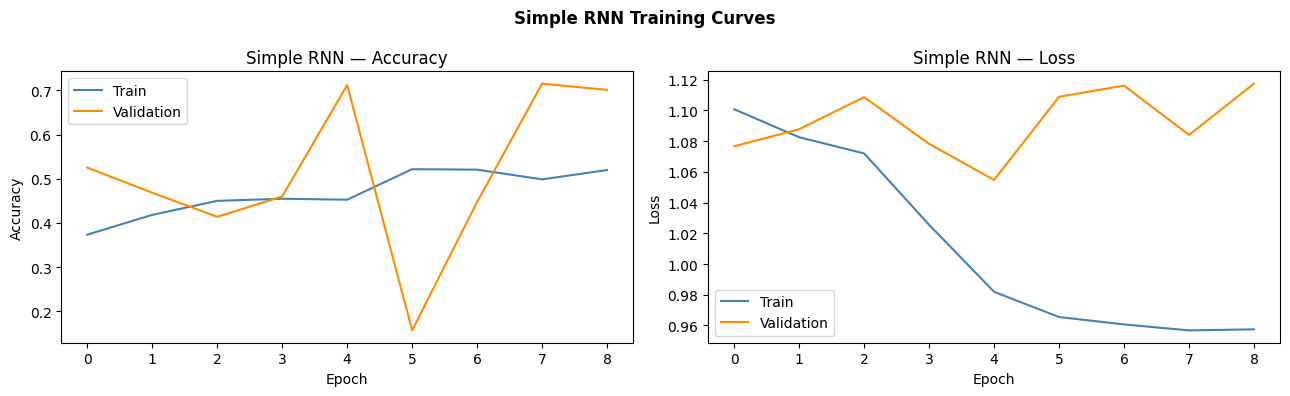

In [ ]:
draw_history(rnn_history, "Simple RNN")


  Simple RNN — Classification Report
              precision    recall  f1-score   support

    Negative       0.16      0.04      0.06       643
     Neutral       0.15      0.03      0.05       437
    Positive       0.74      0.95      0.83      3019

    accuracy                           0.71      4099
   macro avg       0.35      0.34      0.31      4099
weighted avg       0.59      0.71      0.63      4099



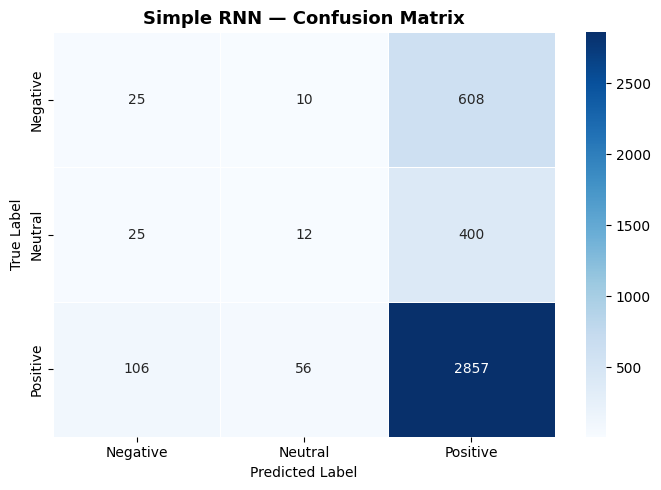

In [ ]:
rnn_preds = assess_model(rnn_model, X_test_pad, y_test_flat, "Simple RNN")

## Step 12 — Model 2: Bidirectional LSTM

### Architecture Rationale
- **Embedding(8000, 100, input_length=seq_max_len)**: Higher-dimensional embeddings (100-d) than Model 1.
- **Bidirectional(LSTM(128, return_sequences=True))**: Reads the sequence forwards AND backwards, capturing both past and future context. `return_sequences=True` passes the full sequence to the next layer.
- **Dropout(0.4)**: Stronger regularisation since the model has more capacity.
- **LSTM(64)**: Second recurrent layer extracts higher-level temporal patterns.
- **Dense(64, relu) → Dense(3, softmax)**: Classification head.

**Why Bidirectional LSTM over simple LSTM?** Hotel reviews often have sentiment words at both the start ("Terrible…") and end ("…would not return"). Bidirectional reading captures both.

In [ ]:
lstm_model = Sequential([
    Embedding(input_dim=word_vocab_size, output_dim=100,
              input_length=seq_max_len),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.4),
    LSTM(64),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
], name="Bidirectional_LSTM")

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Bidirectional_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop_lstm = EarlyStopping(monitor='val_loss', patience=4,
                                 restore_best_weights=True)

t_lstm_start = time.time()
lstm_history = lstm_model.fit(
    X_train_pad, y_train_flat,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop_lstm],
    class_weight=label_weights
)
t_lstm_end = time.time()
lstm_train_time = t_lstm_end - t_lstm_start
print(f"Bidirectional LSTM training time: {lstm_train_time:.1f} seconds")

Epoch 1/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.3371 - loss: 1.0982 - val_accuracy: 0.6880 - val_loss: 1.0748
Epoch 2/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.4362 - loss: 1.0911 - val_accuracy: 0.2400 - val_loss: 1.0536
Epoch 3/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.2745 - loss: 1.0870 - val_accuracy: 0.1122 - val_loss: 1.1384
Epoch 4/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.4225 - loss: 1.0786 - val_accuracy: 0.7219 - val_loss: 1.0985
Epoch 5/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.4688 - loss: 1.0632 - val_accuracy: 0.1513 - val_loss: 1.0878
Epoch 6/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.5730 - loss: 1.0434 - val_accuracy: 0.1244 - val_loss: 1.1533
Bidirectional LSTM training time: 50.7 seconds


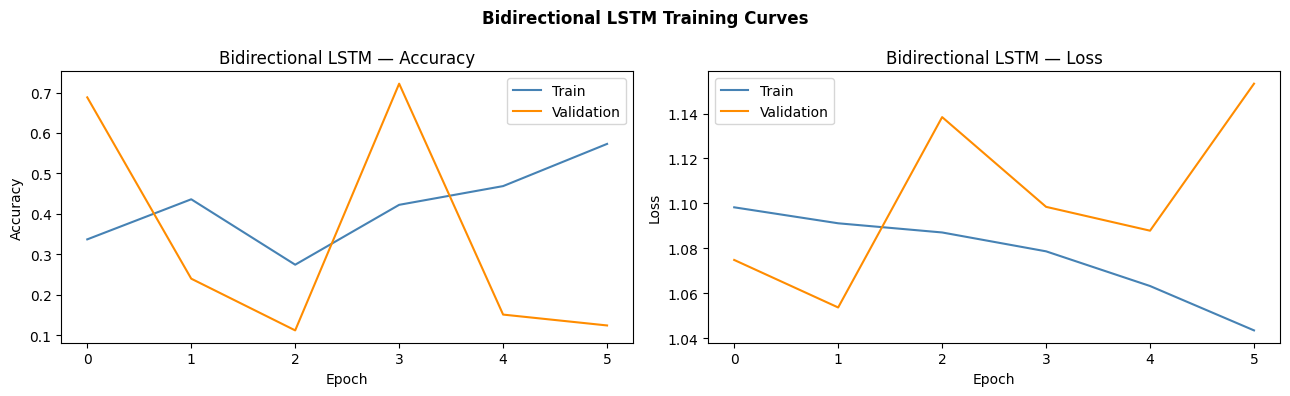

In [ ]:
draw_history(lstm_history, "Bidirectional LSTM")


  Bidirectional LSTM — Classification Report
              precision    recall  f1-score   support

    Negative       0.20      0.31      0.24       643
     Neutral       0.11      0.63      0.18       437
    Positive       0.93      0.15      0.26      3019

    accuracy                           0.23      4099
   macro avg       0.41      0.36      0.23      4099
weighted avg       0.73      0.23      0.25      4099



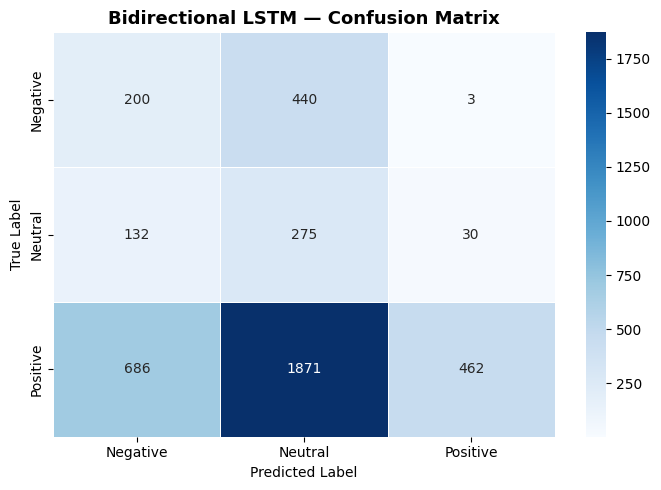

In [ ]:
lstm_preds = assess_model(lstm_model, X_test_pad, y_test_flat, "Bidirectional LSTM")

## Step 13 — Model 3: LSTM with Pretrained GloVe Embeddings

### Why Pretrained Embeddings?
Models 1 and 2 learn word vectors from scratch on ~80k reviews.
**GloVe** (Global Vectors for Word Representation) was trained on billions of web tokens —
it already knows that *excellent* and *outstanding* are similar, and *terrible* and *awful* are similar.
Injecting this prior knowledge into the embedding layer gives the LSTM a richer starting point.

We use **glove-wiki-gigaword-100** (100-dimensional, trained on Wikipedia + Gigaword corpus).

### Install Gensim

In [ ]:
!pip install numpy==1.23.5 --quiet
!pip install gensim --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 112.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 83.2 MB/s eta 0:00:00


In [ ]:
import gensim.downloader as api

print("Loading GloVe vectors — this downloads ~130 MB on first run...")
glove_vectors = api.load("glove-wiki-gigaword-100")
glove_dim = 100
print("GloVe loaded. Vocabulary size:", len(glove_vectors))

Loading GloVe vectors — this downloads ~130 MB on first run...
[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe loaded. Vocabulary size: 400000


### Build GloVe Embedding Matrix

In [ ]:
glove_embed_matrix = np.zeros((word_vocab_size, glove_dim))

hit, miss = 0, 0
for word, idx in keras_tokenizer.word_index.items():
    if idx < word_vocab_size:
        if word in glove_vectors:
            glove_embed_matrix[idx] = glove_vectors[word]
            hit += 1
        else:
            miss += 1

print(f"Words found in GloVe    : {hit}")
print(f"Words NOT found (zeros) : {miss}")
print(f"Coverage                : {hit/(hit+miss)*100:.1f}%")

Words found in GloVe    : 7519
Words NOT found (zeros) : 480
Coverage                : 94.0%


### Define Model 3

In [ ]:
glove_model = Sequential([
    Embedding(
        input_dim=word_vocab_size,
        output_dim=glove_dim,
        weights=[glove_embed_matrix],
        input_length=seq_max_len,
        trainable=False        # freeze GloVe weights
    ),
    LSTM(64),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
], name="GloVe_LSTM")

glove_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

glove_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "GloVe_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │       800,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 800,000 (3.05 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 800,000 (3.05 MB)

In [ ]:
early_stop_glove = EarlyStopping(monitor='val_loss', patience=4,
                                  restore_best_weights=True)

t_glove_start = time.time()
glove_history = glove_model.fit(
    X_train_pad, y_train_flat,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop_glove],
    class_weight=label_weights
)
t_glove_end = time.time()
glove_train_time = t_glove_end - t_glove_start
print(f"GloVe LSTM training time: {glove_train_time:.1f} seconds")

Epoch 1/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.4807 - loss: 1.0963 - val_accuracy: 0.7332 - val_loss: 1.0603
Epoch 2/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.5248 - loss: 1.0882 - val_accuracy: 0.7264 - val_loss: 0.9610
Epoch 3/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.4581 - loss: 1.0957 - val_accuracy: 0.6685 - val_loss: 1.0949
Epoch 4/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5187 - loss: 1.0881 - val_accuracy: 0.7106 - val_loss: 1.0884
Epoch 5/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6626 - loss: 1.0746 - val_accuracy: 0.7246 - val_loss: 1.0768
Epoch 6/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5233 - loss: 1.0506 - val_accuracy: 0.6841 - val_loss: 1.0942
GloVe LSTM training time: 31.7 seconds


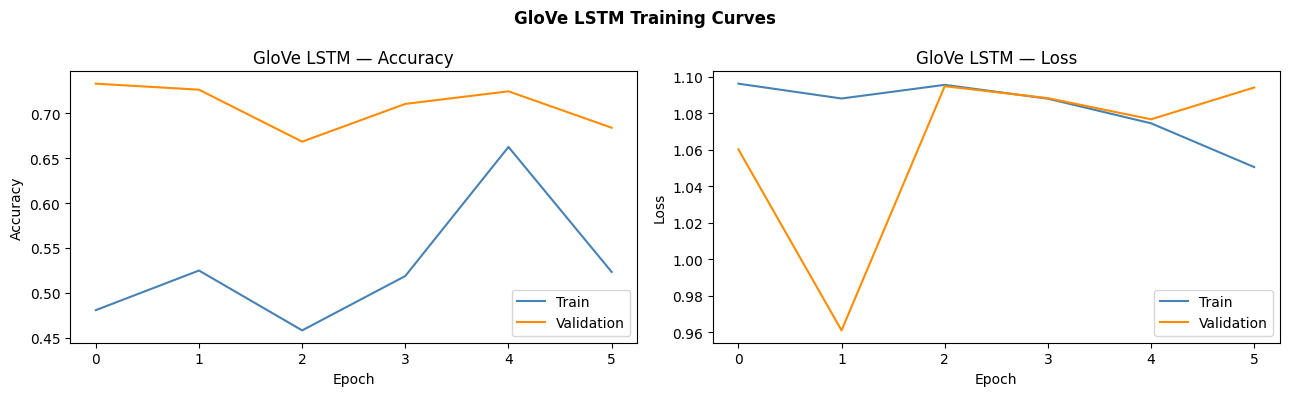

In [ ]:
draw_history(glove_history, "GloVe LSTM")


  GloVe LSTM — Classification Report
              precision    recall  f1-score   support

    Negative       1.00      0.02      0.04       643
     Neutral       0.19      0.03      0.06       437
    Positive       0.74      0.99      0.85      3019

    accuracy                           0.73      4099
   macro avg       0.65      0.35      0.31      4099
weighted avg       0.72      0.73      0.64      4099



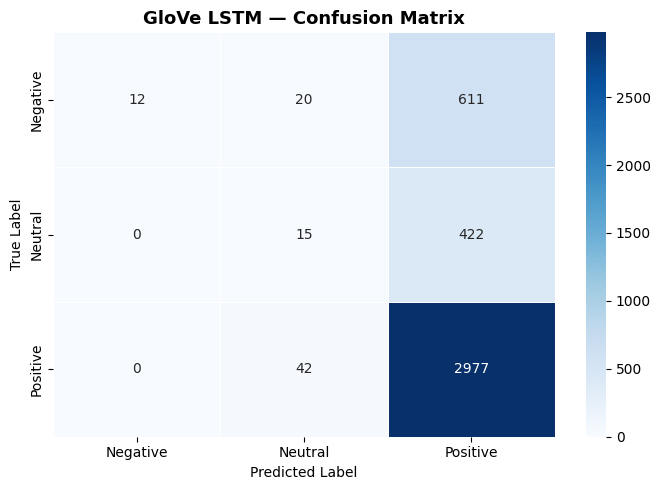

In [ ]:
glove_preds = assess_model(glove_model, X_test_pad, y_test_flat, "GloVe LSTM")

## Step 14 — Model Comparison

### Training Time & Test Accuracy — All 3 Models
We compare all models on computational cost and final test accuracy.

Model                      Test Accuracy  Train Time (s)
Simple RNN                        0.7060            39.3
Bidirectional LSTM                0.2286            50.7
GloVe LSTM                        0.7329            31.7


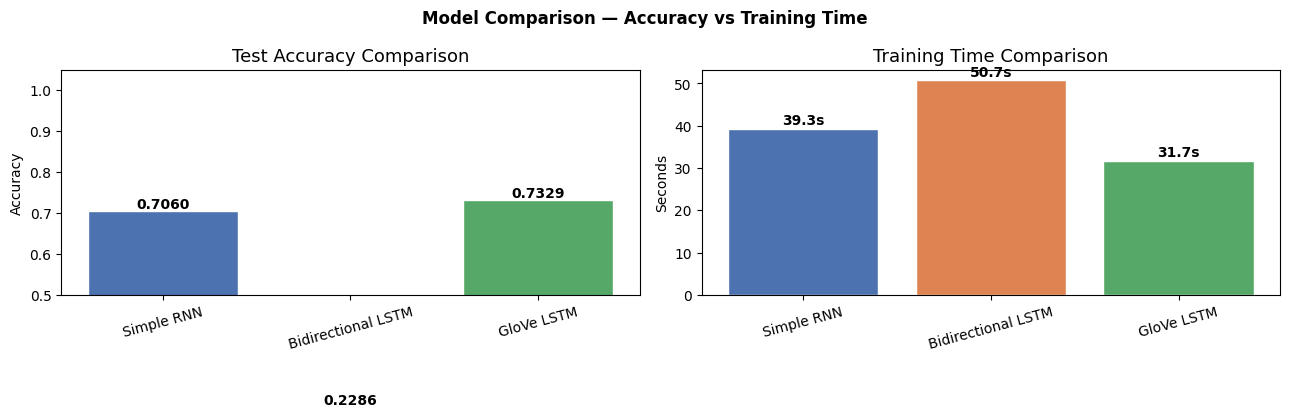

In [ ]:
_, rnn_acc   = rnn_model.evaluate(X_test_pad,   y_test_flat, verbose=0)
_, lstm_acc  = lstm_model.evaluate(X_test_pad,  y_test_flat, verbose=0)
_, glove_acc = glove_model.evaluate(X_test_pad, y_test_flat, verbose=0)

model_names  = ['Simple RNN', 'Bidirectional LSTM', 'GloVe LSTM']
accuracies   = [rnn_acc, lstm_acc, glove_acc]
train_times  = [rnn_train_time, lstm_train_time, glove_train_time]

print(f"{'Model':<25}{'Test Accuracy':>15}{'Train Time (s)':>16}")
print("=" * 58)
for n, a, t in zip(model_names, accuracies, train_times):
    print(f"{n:<25}{a:>15.4f}{t:>16.1f}")

# Side-by-side bar charts
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette = ['#4C72B0', '#DD8452', '#55A868']

axes[0].bar(model_names, accuracies, color=palette, edgecolor='white')
for i, (bar_val, acc) in enumerate(zip(axes[0].patches, accuracies)):
    axes[0].text(i, acc + 0.005, f'{acc:.4f}', ha='center',
                 fontsize=10, fontweight='bold')
axes[0].set_title('Test Accuracy Comparison', fontsize=13)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.5, 1.05)
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(model_names, train_times, color=palette, edgecolor='white')
for i, t in enumerate(train_times):
    axes[1].text(i, t + 1, f'{t:.1f}s', ha='center',
                 fontsize=10, fontweight='bold')
axes[1].set_title('Training Time Comparison', fontsize=13)
axes[1].set_ylabel('Seconds')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Model Comparison — Accuracy vs Training Time', fontweight='bold')
plt.tight_layout()
plt.show()

## Step 15 — Error Analysis

### 15.1 Misclassified Examples
We inspect 3 reviews that the **best model (Bidirectional LSTM)** got wrong
to understand where the model struggles.

In [ ]:
def display_errors(model, X_padded, y_true, original_texts, n_errors=3):
    """Show n misclassified examples with actual vs predicted label."""
    label_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    raw_probs   = model.predict(X_padded, verbose=0)
    pred_labels = np.argmax(raw_probs, axis=1)
    error_idx   = np.where(pred_labels != np.array(y_true))[0]

    print(f"Total misclassified: {len(error_idx)} / {len(y_true)}\n")
    for i in error_idx[:n_errors]:
        print(f"Review   : {original_texts.iloc[i]}")
        print(f"Actual   : {label_map[int(y_true.iloc[i])]}")
        print(f"Predicted: {label_map[int(pred_labels[i])]}")
        print("-" * 60)

display_errors(lstm_model, X_test_pad, y_test, X_test, n_errors=3)

Total misclassified: 3162 / 4099

Review   : amazing hotel believe good review hotel fantastic new york standard hotel clean modern staff nt help especially consierge special mention brooke room spacious bathroom extra clean shower bath room cleaned day evening turn service come long day shopping sightseeing light heat bed ready lay sweet smell room drank bar night expensive service worth bar man special cocktail eat restaraunt fancy great stay sofitel highly recommend definitely staying visit new york
Actual   : Positive
Predicted: Neutral
------------------------------------------------------------
Review   : perfect ca nt recommend place great location friendly service nice clean modern room pool area great relaxing sight pre dinner drink head nice bar restaurant area hard pressed hotel standard reasonable price definitely stay time visit barcelona
Actual   : Positive
Predicted: Neutral
------------------------------------------------------------
Review   : good hotel good location 

### 15.2 Reasons for Errors

1. **Ambiguous / mixed-sentiment reviews** — A review may praise the location but criticise the food in the same sentence. The model receives conflicting signals and defaults to the dominant class.
2. **Sarcasm and implicit sentiment** — *"Oh great, the lift was broken again"* contains the word *great* but is negative. LSTMs rarely detect sarcasm without task-specific pretraining.
3. **Short / sparse reviews** — Very brief reviews (e.g. *"Fine."*) leave almost no tokens after stopword removal, making the prediction unreliable.
4. **Neutral class underrepresentation** — Rating = 3 has far fewer samples. Even with class weighting the model may still confuse Neutral with Positive.

### 15.3 Model Complexity vs Performance

| Model | Parameters | Captures Long-Range | Pretrained Knowledge | Expected Performance |
|---|---|---|---|---|
| Simple RNN | Low | ✗ Vanishing gradient | ✗ | Lowest |
| Bidirectional LSTM | Medium | ✓ | ✗ | Medium |
| GloVe LSTM | Medium | ✓ | ✓ (GloVe 100d) | Highest |

### 15.4 Suggested Improvements

1. **Larger GloVe** — use `glove-wiki-gigaword-300` (300-d) for richer representations.
2. **Fine-tune GloVe** — set `trainable=True` after a few frozen warm-up epochs.
3. **Transformer encoder** — BERT or DistilBERT captures bidirectional context at scale.
4. **Data augmentation** — synonym replacement or back-translation to balance the Neutral class.
5. **Attention mechanism** — self-attention on top of LSTM focuses on sentiment-bearing words.
6. **Hyperparameter tuning** — use Keras Tuner to systematically search LR, units, dropout.

## Step 16 — GUI for Real-Time Prediction (Gradio)

A simple web interface lets users type any hotel review and get an instant sentiment prediction
from the **best-performing model (Bidirectional LSTM)**.

**Pipeline:**
1. User input → `preprocess_text()` (same pipeline as training)
2. Cleaned text → `keras_tokenizer.texts_to_sequences()` → `pad_sequences()`
3. Padded sequence → `lstm_model.predict()` → confidence scores
4. Gradio displays the predicted label and confidence bar chart.

In [ ]:
import gradio as gr
from tensorflow.keras.preprocessing.sequence import pad_sequences

sentiment_map = {0: "Negative 😞", 1: "Neutral 😐", 2: "Positive 😊"}

def predict_sentiment(review_input):
    """Preprocess input and return sentiment prediction + confidence."""
    if not review_input.strip():
        return "Please enter a review.", {}

    cleaned_input = preprocess_text(review_input)
    seq           = keras_tokenizer.texts_to_sequences([cleaned_input])
    padded_seq    = pad_sequences(seq, maxlen=seq_max_len, padding='post')

    prob_scores   = lstm_model.predict(padded_seq, verbose=0)[0]
    predicted_cls = int(np.argmax(prob_scores))

    confidence = {sentiment_map[i]: float(round(prob_scores[i], 4)) for i in range(3)}
    return sentiment_map[predicted_cls], confidence


review_ui = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=4,
                      placeholder="Type a hotel review here...",
                      label="Hotel Review"),
    outputs=[
        gr.Text(label="Predicted Sentiment"),
        gr.Label(label="Confidence Scores", num_top_classes=3)
    ],
    title="Hotel Review Sentiment Classifier",
    description=(
        "Enter a hotel review. The Bidirectional LSTM model predicts whether "
        "the sentiment is Positive, Neutral, or Negative."
    ),
    examples=[
        ["The room was spotless and the staff incredibly helpful. Will definitely return!"],
        ["Check-in was okay, nothing special. Room was average for the price."],
        ["Terrible experience. Noisy, dirty room and rude reception staff."],
    ],
    allow_flagging="never"
)

review_ui.launch(share=True)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://00de18d4ecf908234a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
